In [1]:
# Blocco 1: Setup e Importazioni (TensorFlow/Keras)
# =================================================
# Importa le librerie necessarie

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold # Useremo i fold predefiniti
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# --- Configurazioni Iniziali ---
# TensorFlow tende a usare tutta la memoria GPU disponibile. Puoi limitarla se necessario.
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Attualmente, la crescita dinamica della memoria è abilitata di default in TF 2.x
        # Quindi non è strettamente necessario configurarla manualmente, ma può essere utile
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Utilizzo GPU con crescita di memoria dinamica.")
    except RuntimeError as e:
        print(e) # La crescita della memoria deve essere impostata all'avvio

DEVICE_NAME = tf.test.gpu_device_name() if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"Using device: {DEVICE_NAME}")


# Percorsi (assicurati che siano corretti per il tuo ambiente)
BASE_DATA_PATH = "../data" # Modifica se necessario
META_FILE_PATH = os.path.join(BASE_DATA_PATH, "raw/UrbanSound8K.csv")
FEATURES_PATH = os.path.join(BASE_DATA_PATH, "processed/features") # Cartella contenente fold1, fold2, ... con i .npz

# Parametri del modello e training
NUM_CLASSES = 10  # UrbanSound8K ha 10 classi
LEARNING_RATE = 0.001
BATCH_SIZE = 32
NUM_EPOCHS = 10
FEATURE_TYPE = 'log_mel_spec' # 'log_mel_spec' o 'mfcc'

# Per riproducibilità
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Carica i metadati una volta
try:
    metadata_df = pd.read_csv(META_FILE_PATH)
except FileNotFoundError:
    print(f"Errore: File metadati non trovato in {META_FILE_PATH}. Verifica il percorso.")
    exit()

print(f"Metadati caricati. Numero totale di campioni: {len(metadata_df)}")

Using device: /CPU:0
Metadati caricati. Numero totale di campioni: 8732


In [2]:
import tensorflow as tf

print(f"TensorFlow Version: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

if gpus:
    print("GPUs found:", gpus)
    try:
        # Configura la crescita della memoria per ogni GPU rilevata
        # Questo è importante per evitare che TensorFlow allochi tutta la memoria GPU all'avvio
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for GPUs")

        # Esegui un semplice calcolo sulla GPU per testare
        with tf.device('/GPU:0'): # Assumendo che la prima GPU sia /GPU:0
            a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
            b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
            c = tf.matmul(a, b)
        print("Matrix multiplication on GPU successful:\n", c.numpy())

    except RuntimeError as e:
        print("RuntimeError:", e)
else:
    print("No GPU found by TensorFlow. Ensure your NVIDIA drivers are up to date and support CUDA.")

TensorFlow Version: 2.19.0
Num GPUs Available:  0
No GPU found by TensorFlow. Ensure your NVIDIA drivers are up to date and support CUDA.


In [3]:
# Blocco 2: Definizione della Classe Data Generator (TensorFlow/Keras)
# ====================================================================
# keras.utils.Sequence è l'equivalente di torch.utils.data.Dataset per il training multi-processo

class UrbanSoundDataGenerator(keras.utils.Sequence):
    def __init__(self, metadata_df, features_base_path, folds_to_include, batch_size,
                 feature_type='log_mel_spec', num_classes=10, shuffle=True):
        """
        Args:
            metadata_df (pd.DataFrame): DataFrame con i metadati.
            features_base_path (str): Percorso base alla cartella 'features'.
            folds_to_include (list): Lista di numeri di fold da includere.
            batch_size (int): Dimensione del batch.
            feature_type (str): 'log_mel_spec' o 'mfcc'.
            num_classes (int): Numero di classi per one-hot encoding.
            shuffle (bool): Se mescolare i dati ad ogni epoca.
        """
        self.metadata_df = metadata_df
        self.features_base_path = features_base_path
        self.folds_to_include = folds_to_include
        self.batch_size = batch_size
        self.feature_type = feature_type
        self.num_classes = num_classes
        self.shuffle = shuffle

        self.file_paths = []
        self.labels = []
        self._load_file_paths_and_labels()
        
        self.indexes = np.arange(len(self.file_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)
            
        # Determina la forma dell'input (da uno dei file .npz)
        self.input_shape = self._get_input_shape()
        if self.input_shape is None:
            # Potrebbe essere necessario definire una forma fissa se il caricamento fallisce
            # o gestire l'errore più robustamente
            print("Attenzione: Impossibile determinare input_shape. Verifica i file .npz.")
            if self.feature_type == 'log_mel_spec':
                # Esempio di shape, da verificare: (n_mels, n_frames, 1 canale)
                # Keras si aspetta (altezza, larghezza, canali) per Conv2D
                self.input_shape = (128, 173, 1) # Altezza, Larghezza, Canali. VERIFICA QUESTI VALORI!
            else: # mfcc
                self.input_shape = (20, 173, 1) # VERIFICA QUESTI VALORI!


    def _load_file_paths_and_labels(self):
        df_subset = self.metadata_df[self.metadata_df['fold'].isin(self.folds_to_include)]
        for _, row in tqdm(df_subset.iterrows(), total=len(df_subset), desc=f"Caricamento per fold {self.folds_to_include}"):
            filename = row['slice_file_name']
            fold_num = row['fold']
            class_id = row['classID']
            
            base_name = os.path.splitext(filename)[0]
            npz_path = os.path.join(self.features_base_path, f"fold{fold_num}", f"{base_name}.npz")

            if os.path.exists(npz_path):
                self.file_paths.append(npz_path)
                self.labels.append(class_id)
            # else:
            #     print(f"Attenzione: file feature non trovato: {npz_path}") # Può essere rumoroso
        print(f"Trovati {len(self.file_paths)} file per i fold {self.folds_to_include}")


    def _get_input_shape(self):
        if not self.file_paths:
            return None
        try:
            sample_path = self.file_paths[0]
            data = np.load(sample_path)
            if self.feature_type == 'log_mel_spec':
                features = data['log_mel_spec']
            else:
                features = data['mfcc']
            # Keras Conv2D si aspetta (altezza, larghezza, canali)
            return (features.shape[0], features.shape[1], 1) # Aggiungiamo il canale
        except Exception as e:
            print(f"Errore nel caricare il file campione per shape: {e}")
            return None

    def __len__(self):
        # Numero di batch per epoca
        return int(np.floor(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        # Genera indici per un batch
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        # Trova la lista degli ID dei file per questo batch
        batch_file_paths = [self.file_paths[k] for k in batch_indexes]
        batch_labels = [self.labels[k] for k in batch_indexes]

        # Genera i dati
        X, y = self._data_generation(batch_file_paths, batch_labels)
        return X, y

    def on_epoch_end(self):
        # Mescola gli indici alla fine di ogni epoca se shuffle=True
        self.indexes = np.arange(len(self.file_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def _data_generation(self, batch_file_paths, batch_labels):
        # Inizializza array per il batch
        # L'input_shape è (H, W, C) quindi X sarà (batch_size, H, W, C)
        X = np.empty((len(batch_file_paths), *self.input_shape))
        y = np.empty((len(batch_file_paths)), dtype=int)

        for i, file_path in enumerate(batch_file_paths):
            try:
                data = np.load(file_path)
                if self.feature_type == 'log_mel_spec':
                    features = data['log_mel_spec'] # Shape (H, W)
                else:
                    features = data['mfcc'] # Shape (H, W)
                
                # Aggiungi la dimensione del canale: (H, W) -> (H, W, 1)
                X[i,] = np.expand_dims(features, axis=-1)
                y[i] = batch_labels[i]
            except Exception as e:
                print(f"Errore caricando {file_path}: {e}. Sostituendo con zeri.")
                # Gestisci l'errore, ad esempio riempiendo con zeri
                # o saltando il campione (ma questo complica la dimensione del batch)
                X[i,] = np.zeros(self.input_shape) 
                y[i] = 0 # Etichetta dummy

        # Converti le etichette in one-hot encoding se la loss è categorical_crossentropy
        # Se la loss è sparse_categorical_crossentropy, non serve
        # return X, keras.utils.to_categorical(y, num_classes=self.num_classes)
        return X, y # Per sparse_categorical_crossentropy

In [4]:
# Blocco 3: Definizione del Modello (CNN + GRU) con Keras Functional API
# =======================================================================

def build_cnngru_model(input_shape, num_classes, feature_type='log_mel_spec', 
                       cnn_filters=64, gru_units=128, gru_layers=1):
    
    inputs = keras.Input(shape=input_shape) # Es: (128, 173, 1) per log_mel_spec

    # --- Strati CNN ---
    # Keras Conv2D per default usa 'channels_last' data_format (batch, height, width, channels)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(cnn_filters, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    # MaxPool per ridurre la dimensione della frequenza, mantenendo quella temporale
    x = layers.MaxPooling2D((2, 1))(x) # (pool_size_y, pool_size_x)

    # --- Prepara l'output della CNN per la GRU ---
    # L'output della CNN è (batch, H_cnn, W_cnn, Filters_cnn)
    # La GRU si aspetta (batch, timesteps, features)
    # Dobbiamo riorganizzare: H_cnn diventa la dimensione delle feature per ogni timestep
    # W_cnn diventa la dimensione dei timesteps
    
    # Ottieni la forma dopo la CNN (escluso il batch)
    # TensorFlow non ha un modo semplice per ottenere la forma esatta qui senza eseguire
    # Quindi è più sicuro usare Reshape o Permute basandosi sulla conoscenza dell'output della CNN
    # Oppure, un approccio comune è "appiattire" la dimensione della frequenza nei canali
    
    # Shape dopo l'ultimo MaxPool2D(2,1): (batch, H_cnn_out, W_cnn_out, cnn_filters)
    # Vogliamo (batch, W_cnn_out, H_cnn_out * cnn_filters) per la GRU
    
    # Permute per portare la dimensione temporale (larghezza) prima
    # x = layers.Permute((2, 1, 3))(x) # (batch, W_cnn_out, H_cnn_out, cnn_filters)
    # x = layers.Reshape((-1, x.shape[2] * x.shape[3]))(x) # (batch, W_cnn_out, H_cnn_out * cnn_filters)
    
    # Approccio più semplice, usando GlobalAveragePooling sulla dimensione delle frequenze
    # o TimeDistributed(Flatten())
    # Se usiamo GlobalAveragePooling2D((1,None)) come in PyTorch:
    # Questo appiattirebbe la dimensione delle frequenze mantenendo quella temporale
    # Ma in Keras è più comune lasciare che la CNN faccia il suo lavoro e poi Reshape
    # Per la GRU, vogliamo che la sequenza sia la dimensione temporale.
    # L'output da CNN (batch, new_height, new_width, channels)
    # Per la GRU: (batch, timesteps, features)
    # Qui, new_width è timesteps. features = new_height * channels
    
    # Reshape: ottieni la forma dell'output dalla CNN
    # La dimensione temporale è la seconda (-2), le feature sono (prima * ultima)
    # (batch_size, height, width, channels) -> (batch_size, width, height * channels)
    # Quindi, prima permuta e poi reshape
    # x = layers.Permute((2,1,3))(x) # (batch, width, height, channels)
    # Questo è equivalente a:
    # target_shape = (-1, x.shape[2] * x.shape[3]) # (width, height*channels)
    # x = layers.Reshape(target_shape)(x)

    # Modo più robusto: estrarre le dimensioni dinamicamente
    # Dopo la CNN, x ha shape (batch_size, conv_h, conv_w, conv_channels)
    # Vogliamo che la GRU riceva (batch_size, conv_w, conv_h * conv_channels)
    # conv_w sono i timesteps
    # conv_h * conv_channels sono le feature per timestep

    # Il modo più diretto per passare da Conv2D a RNN è usare un TimeDistributed wrapper
    # attorno a un Flatten se le feature spaziali sono per ogni timestep.
    # Oppure, se vuoi "appiattire" la dimensione della frequenza:
    # new_shape = (x.shape[1], x.shape[2] * x.shape[3]) # (timesteps, features)
    # x = layers.Reshape(target_shape=(-1, x.shape[2] * x.shape[3]))(x)
    
    # L'approccio con AdaptiveAvgPool del codice PyTorch era:
    # x = self.adaptive_pool(x) # Shape: (batch, cnn_out_channels, 1, W_cnn_out)
    # x = x.squeeze(2)          # Shape: (batch, cnn_out_channels, W_cnn_out)
    # x = x.permute(0, 2, 1)    # Shape: (batch, W_cnn_out, cnn_out_channels)
    # In Keras, questo è layers.Reshape((timesteps, features_per_timestep))
    # Se l'output della CNN è (batch, H, W, C), e W sono i timesteps, features_per_timestep è H*C
    # Se l'output della CNN è (batch, H_cnn_out, W_cnn_out, cnn_filters)
    # e W_cnn_out è la dimensione temporale, allora le features per timestep sono H_cnn_out * cnn_filters.
    # Reshape(-1, dim1*dim2) non funziona se -1 non è il primo.
    # Più semplice: usa la forma conosciuta dopo la CNN.
    # Se l'input alla GRU deve essere (batch, timesteps, features):
    # E l'output della CNN è (batch, H_out, W_out, C_out)
    # Allora timesteps = W_out, features = H_out * C_out
    # Quindi reshapa l'output della CNN in (batch, W_out, H_out * C_out)
    
    # Dopo l'ultimo MaxPool2D((2,1)), la forma sarà (batch, H_cnn/8, W_cnn/4, cnn_filters)
    # Chiamiamo queste dimensioni H_final, W_final, C_final
    # Vogliamo alimentare la GRU con (batch, W_final, H_final * C_final)
    
    # Un modo per farlo dinamicamente:
    # shape_before_gru = tf.shape(x) # Ottiene la forma dinamica
    # B, H, W, C = shape_before_gru[0], shape_before_gru[1], shape_before_gru[2], shape_before_gru[3]
    # x = tf.reshape(x, [B, W, H * C]) # Questo richiede che H e C siano noti a tempo di compilazione
                                      # O usa layers.Reshape
    
    # Assumendo che l'output della CNN sia (batch, H_feature_map, W_timesteps, Channels)
    # Dobbiamo convertirlo in (batch, W_timesteps, H_feature_map * Channels)
    # La layers.Reshape in Keras appiattisce a partire dall'ultima dimensione.
    # Se l'output è (None, H, W, C), layers.Reshape((W, H*C)) dovrebbe funzionare
    # se W, H, C sono noti.
    # Se il tuo input_shape è (128, 173, 1)
    # CNN1: (128,173,16) -> MP1(2,2): (64,86,16) (approx 173/2=86.5)
    # CNN2: (64,86,32) -> MP2(2,2): (32,43,32)
    # CNN3: (32,43,64) -> MP3(2,1): (16,43,64) -> H_final=16, W_final=43, C_final=64
    # Quindi per GRU: (batch, 43, 16*64)
    
    # Questo calcolo manuale è incline a errori. Un layer di Reshape è più pulito se conosci le dimensioni.
    # Keras solitamente inferisce le dimensioni.
    # L'approccio più semplice è "appiattire" le feature spaziali per ogni timestep.
    # Se l'output della CNN è (batch, freq_dim, time_dim, channels), e vogliamo (batch, time_dim, features)
    # Bisogna "unire" freq_dim e channels.
    
    # Dopo l'ultimo MaxPool2D(2,1), l'output è x
    # Vogliamo che la dimensione temporale (larghezza) sia la seconda dimensione per la GRU
    # e le altre dimensioni (altezza e canali) siano fuse.
    # x = layers.Permute((2, 1, 3))(x)  # (batch, W_cnn_out, H_cnn_out, cnn_filters)
    # new_shape_for_gru = (-1, x.shape[2] * x.shape[3]) # (W_cnn_out, H_cnn_out*cnn_filters)
    # x = layers.Reshape(target_shape=new_shape_for_gru)(x)
    
    # Un modo più robusto, usando `TimeDistributed`
    # Applica un layer (es. Flatten) a ogni "fetta" temporale dell'output della CNN
    # L'output della CNN è (batch, freq_dim, time_dim, channels)
    # Dobbiamo prima scambiare freq_dim e time_dim
    x = layers.Permute((2, 1, 3))(x) # (batch, time_dim, freq_dim, channels)
    # Ora ogni fetta temporale è (freq_dim, channels). Appiattiamola.
    x = layers.TimeDistributed(layers.Flatten())(x) # Output: (batch, time_dim, freq_dim * channels)

    # --- Strato GRU ---
    # `return_sequences=False` per l'ultimo strato GRU se non è seguito da un altro RNN
    # o se vogliamo solo l'ultimo output. Se ci sono più strati GRU, i precedenti devono avere return_sequences=True.
    is_last_gru = (gru_layers == 1)
    for i in range(gru_layers):
        x = layers.Bidirectional(layers.GRU(gru_units, return_sequences=(not is_last_gru if i == gru_layers -1 else True)))(x)
        # Aggiungi Dropout se vuoi
        # x = layers.Dropout(0.3)(x)


    # --- Strato Fully Connected per Classificazione ---
    outputs = layers.Dense(num_classes, activation='softmax')(x) # Se la GRU ritorna solo l'ultimo stato
                                                                # Se return_sequences=True, l'output di GRU è (batch, timesteps, features)
                                                                # e dovresti prendere l'ultimo o fare pooling.
                                                                # Qui Bidirectional(GRU(return_sequences=False)) è corretto
                                                                # perché l'output è già (batch, gru_units*2)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Esempio per ottenere l'input_shape dal generator
# (questo è solo per testare la costruzione del modello fuori dal loop)
# temp_gen = UrbanSoundDataGenerator(metadata_df, FEATURES_PATH, [1], BATCH_SIZE, FEATURE_TYPE)
# if temp_gen.input_shape:
#     model_test = build_cnngru_model(temp_gen.input_shape, NUM_CLASSES, FEATURE_TYPE)
#     model_test.summary()
# else:
#     print("Impossibile testare la costruzione del modello, input_shape non determinato.")

In [ ]:
# Blocco 4: Funzioni per Compilazione, Training e Valutazione (Keras)
# ===================================================================
# Keras gestisce gran parte del loop di training con model.fit()

# Non sono necessarie funzioni separate train_epoch e evaluate_model come in PyTorch
# model.compile() e model.fit() fanno il lavoro.

In [5]:
# Blocco 5: Funzioni Ausiliarie (TensorFlow/Keras)
# =================================================
# (Stessa funzione plot_confusion_matrix di prima)

def plot_confusion_matrix_tf(cm, class_names, fold_num):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix - Fold {fold_num} (TF)')
    plt.show()

# Ottieni i nomi delle classi
class_names = sorted(metadata_df['class'].unique())

# Se vuoi implementare Focal Loss per Keras:
# Puoi definirla come una funzione custom e passarla a model.compile()
# Esempio (semplificato, potresti trovare implementazioni più robuste online):
# def focal_loss(gamma=2., alpha=.25):
#     def focal_loss_fixed(y_true, y_pred):
#         pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
#         pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
#         return -tf.reduce_sum(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1)) \
#                -tf.reduce_sum((1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0))
#     return focal_loss_fixed


--- Inizio Fold 1/10 (TensorFlow/Keras) ---
Fold di Training: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Fold di Test: [1]


Caricamento per fold [2, 3, 4, 5, 6, 7, 8, 9, 10]:   0%|          | 0/7859 [00:00<?, ?it/s]

Trovati 7859 file per i fold [2, 3, 4, 5, 6, 7, 8, 9, 10]


Caricamento per fold [1]:   0%|          | 0/873 [00:00<?, ?it/s]

Trovati 873 file per i fold [1]
Inizio training per fold 1...


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 169s 671ms/step - accuracy: 0.6160 - loss: 1.1389 - val_accuracy: 0.6447 - val_loss: 1.1138
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 65s 267ms/step - accuracy: 0.9087 - loss: 0.3059 - val_accuracy: 0.6262 - val_loss: 1.2276
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 66s 269ms/step - accuracy: 0.9729 - loss: 0.1139 - val_accuracy: 0.6586 - val_loss: 1.1841
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 65s 264ms/step - accuracy: 0.9916 - loss: 0.0439 - val_accuracy: 0.6852 - val_loss: 1.1801
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 65s 263ms/step - accuracy: 0.9955 - loss: 0.0252 - val_accuracy: 0.6736 - val_loss: 1.2300
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 64s 263ms/step - accuracy: 0.9994 - loss: 0.0085 - val_accuracy: 0.6759 - val_loss: 1.3934
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 65s 264ms/step - accuracy: 0.9974 - loss: 0.0117 - val_accuracy: 0.6574 - val_loss: 1.4724
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 64s 263ms/step - accuracy: 0.9994 - loss: 

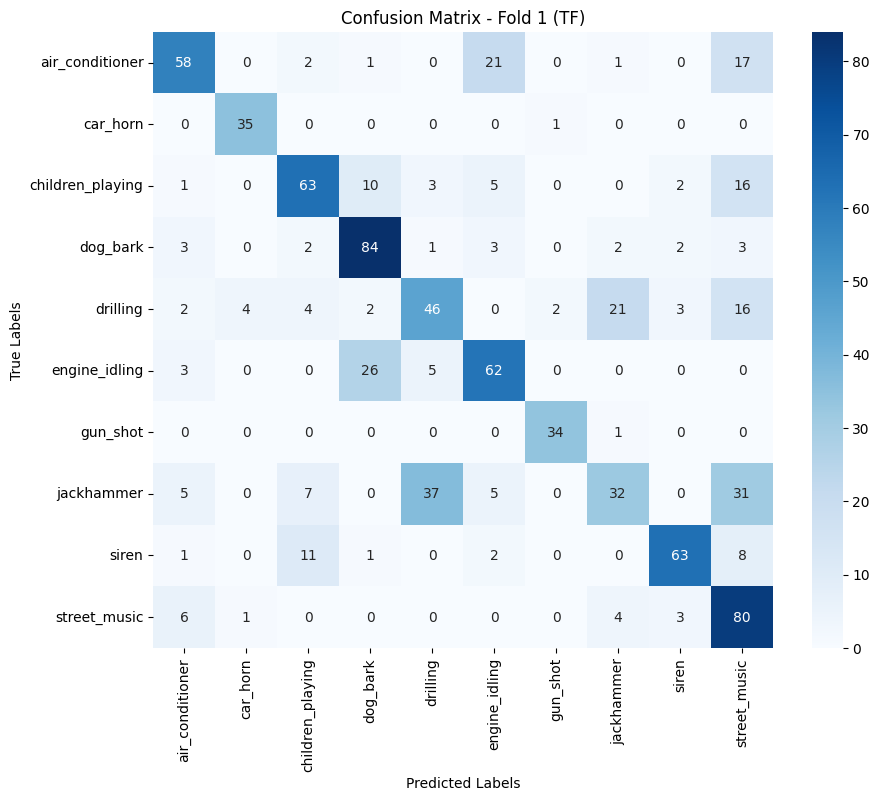



--- Inizio Fold 2/10 (TensorFlow/Keras) ---
Fold di Training: [1, 3, 4, 5, 6, 7, 8, 9, 10]
Fold di Test: [2]


Caricamento per fold [1, 3, 4, 5, 6, 7, 8, 9, 10]:   0%|          | 0/7844 [00:00<?, ?it/s]

Trovati 7844 file per i fold [1, 3, 4, 5, 6, 7, 8, 9, 10]


Caricamento per fold [2]:   0%|          | 0/888 [00:00<?, ?it/s]

Trovati 888 file per i fold [2]
Inizio training per fold 2...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


245/245 ━━━━━━━━━━━━━━━━━━━━ 69s 264ms/step - accuracy: 0.6137 - loss: 1.1599 - val_accuracy: 0.6447 - val_loss: 1.2180
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 65s 263ms/step - accuracy: 0.9089 - loss: 0.3009 - val_accuracy: 0.6794 - val_loss: 1.4682
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 66s 268ms/step - accuracy: 0.9722 - loss: 0.1161 - val_accuracy: 0.6782 - val_loss: 1.3251
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 65s 264ms/step - accuracy: 0.9919 - loss: 0.0456 - val_accuracy: 0.6667 - val_loss: 1.5227
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 63s 259ms/step - accuracy: 0.9986 - loss: 0.0168 - val_accuracy: 0.6725 - val_loss: 1.6214
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 63s 258ms/step - accuracy: 0.9999 - loss: 0.0053 - val_accuracy: 0.6840 - val_loss: 1.9027
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 63s 258ms/step - accuracy: 0.9996 - loss: 0.0046 - val_accuracy: 0.7188 - val_loss: 1.7561
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 64s 263ms/step - accuracy: 1.0000 - loss: 0.0018 - val

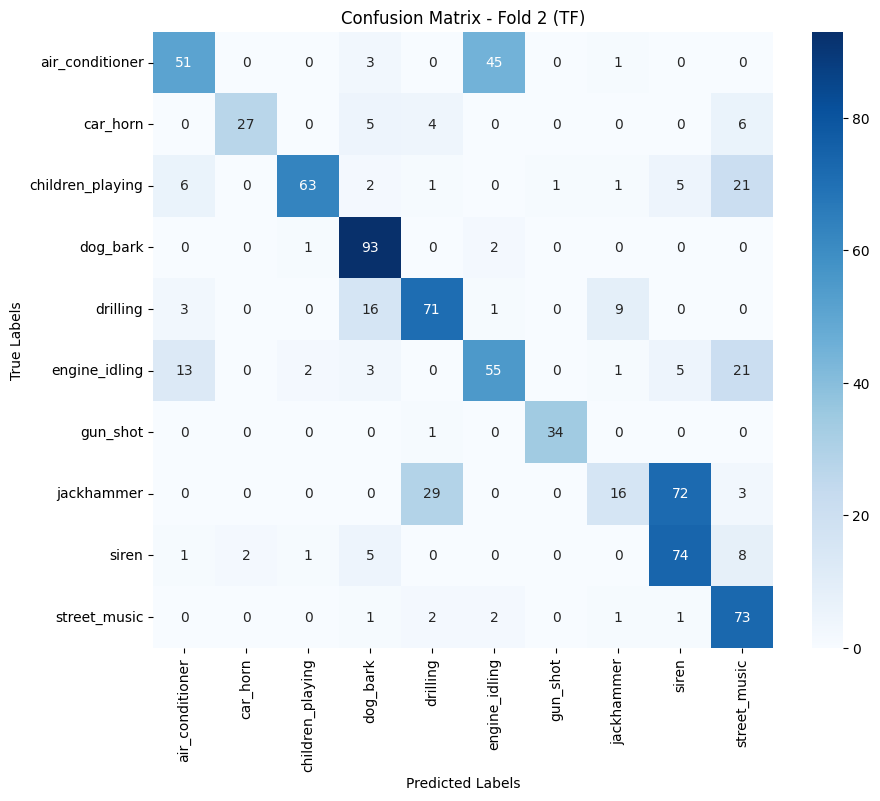


--- Inizio Fold 3/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 4, 5, 6, 7, 8, 9, 10]
Fold di Test: [3]


Caricamento per fold [1, 2, 4, 5, 6, 7, 8, 9, 10]:   0%|          | 0/7807 [00:00<?, ?it/s]

Trovati 7807 file per i fold [1, 2, 4, 5, 6, 7, 8, 9, 10]


Caricamento per fold [3]:   0%|          | 0/925 [00:00<?, ?it/s]

Trovati 925 file per i fold [3]
Inizio training per fold 3...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


243/243 ━━━━━━━━━━━━━━━━━━━━ 68s 263ms/step - accuracy: 0.6317 - loss: 1.1470 - val_accuracy: 0.5759 - val_loss: 1.4214
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 260ms/step - accuracy: 0.9102 - loss: 0.2932 - val_accuracy: 0.6105 - val_loss: 1.3624
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 261ms/step - accuracy: 0.9720 - loss: 0.1152 - val_accuracy: 0.6462 - val_loss: 1.5526
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 64s 261ms/step - accuracy: 0.9879 - loss: 0.0522 - val_accuracy: 0.6138 - val_loss: 1.8299
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 259ms/step - accuracy: 0.9958 - loss: 0.0221 - val_accuracy: 0.6138 - val_loss: 1.9292
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 259ms/step - accuracy: 0.9988 - loss: 0.0094 - val_accuracy: 0.6451 - val_loss: 1.8843
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 260ms/step - accuracy: 0.9977 - loss: 0.0107 - val_accuracy: 0.6306 - val_loss: 1.8161
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 259ms/step - accuracy: 0.9975 - loss: 0.0099 - val

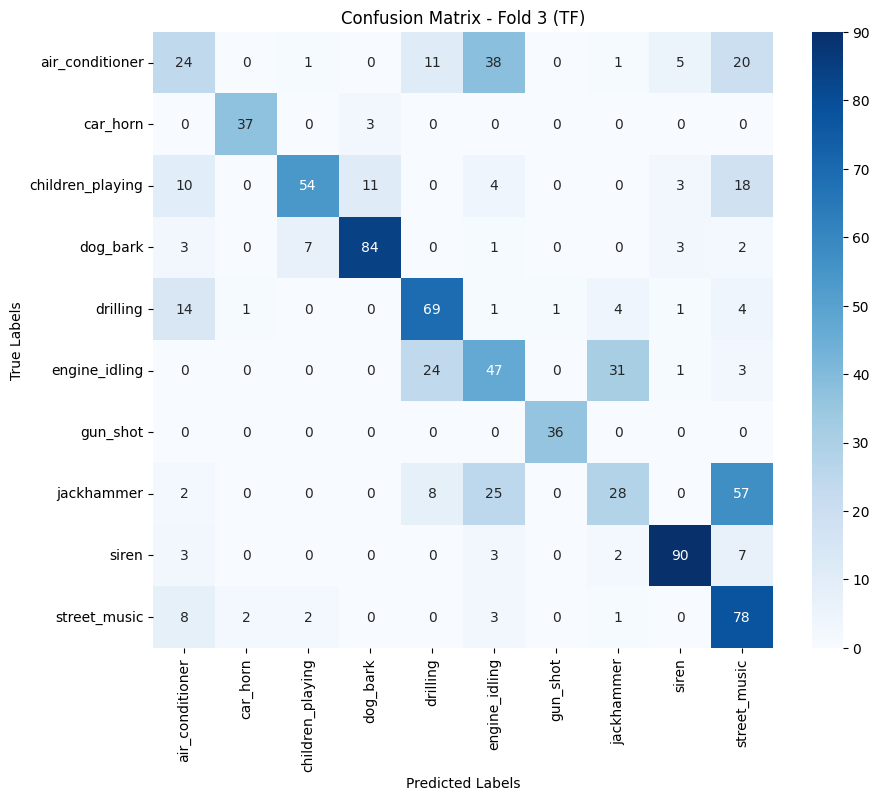


--- Inizio Fold 4/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 3, 5, 6, 7, 8, 9, 10]
Fold di Test: [4]


Caricamento per fold [1, 2, 3, 5, 6, 7, 8, 9, 10]:   0%|          | 0/7742 [00:00<?, ?it/s]

Trovati 7742 file per i fold [1, 2, 3, 5, 6, 7, 8, 9, 10]


Caricamento per fold [4]:   0%|          | 0/990 [00:00<?, ?it/s]

Trovati 990 file per i fold [4]
Inizio training per fold 4...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


241/241 ━━━━━━━━━━━━━━━━━━━━ 67s 262ms/step - accuracy: 0.6146 - loss: 1.1358 - val_accuracy: 0.6542 - val_loss: 0.9878
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 63s 263ms/step - accuracy: 0.9045 - loss: 0.3059 - val_accuracy: 0.7240 - val_loss: 0.8134
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 64s 266ms/step - accuracy: 0.9664 - loss: 0.1242 - val_accuracy: 0.6844 - val_loss: 1.0101
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 63s 260ms/step - accuracy: 0.9858 - loss: 0.0570 - val_accuracy: 0.7542 - val_loss: 0.8714
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 63s 262ms/step - accuracy: 0.9968 - loss: 0.0210 - val_accuracy: 0.7135 - val_loss: 0.9564
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 62s 259ms/step - accuracy: 0.9982 - loss: 0.0116 - val_accuracy: 0.7344 - val_loss: 0.9194
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 63s 263ms/step - accuracy: 0.9981 - loss: 0.0096 - val_accuracy: 0.7052 - val_loss: 1.0867
Epoch 8/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 63s 262ms/step - accuracy: 0.9991 - loss: 0.0059 - val

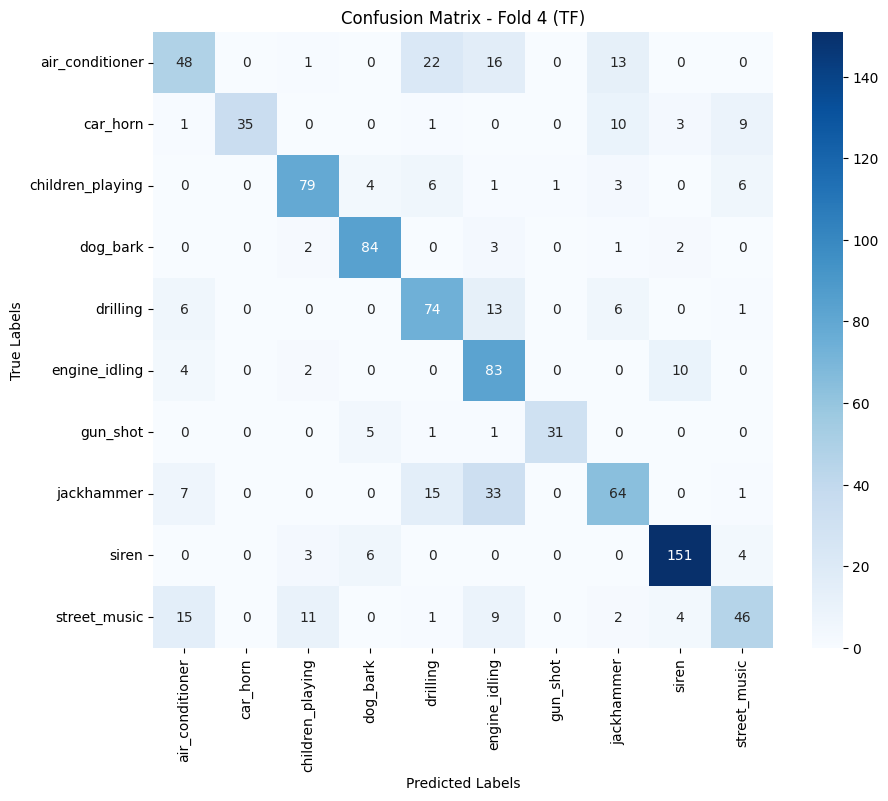


--- Inizio Fold 5/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 3, 4, 6, 7, 8, 9, 10]
Fold di Test: [5]


Caricamento per fold [1, 2, 3, 4, 6, 7, 8, 9, 10]:   0%|          | 0/7796 [00:00<?, ?it/s]

Trovati 7796 file per i fold [1, 2, 3, 4, 6, 7, 8, 9, 10]


Caricamento per fold [5]:   0%|          | 0/936 [00:00<?, ?it/s]

Trovati 936 file per i fold [5]
Inizio training per fold 5...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


243/243 ━━━━━━━━━━━━━━━━━━━━ 68s 262ms/step - accuracy: 0.6043 - loss: 1.1799 - val_accuracy: 0.7349 - val_loss: 0.7670
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 261ms/step - accuracy: 0.9136 - loss: 0.3025 - val_accuracy: 0.7899 - val_loss: 0.6388
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 260ms/step - accuracy: 0.9685 - loss: 0.1198 - val_accuracy: 0.7942 - val_loss: 0.6497
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 64s 263ms/step - accuracy: 0.9896 - loss: 0.0558 - val_accuracy: 0.7931 - val_loss: 0.6387
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 64s 262ms/step - accuracy: 0.9960 - loss: 0.0233 - val_accuracy: 0.8114 - val_loss: 0.5490
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 65s 266ms/step - accuracy: 0.9972 - loss: 0.0162 - val_accuracy: 0.7953 - val_loss: 0.7336
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 64s 264ms/step - accuracy: 0.9990 - loss: 0.0058 - val_accuracy: 0.7909 - val_loss: 0.8624
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 64s 262ms/step - accuracy: 0.9991 - loss: 0.0056 - val

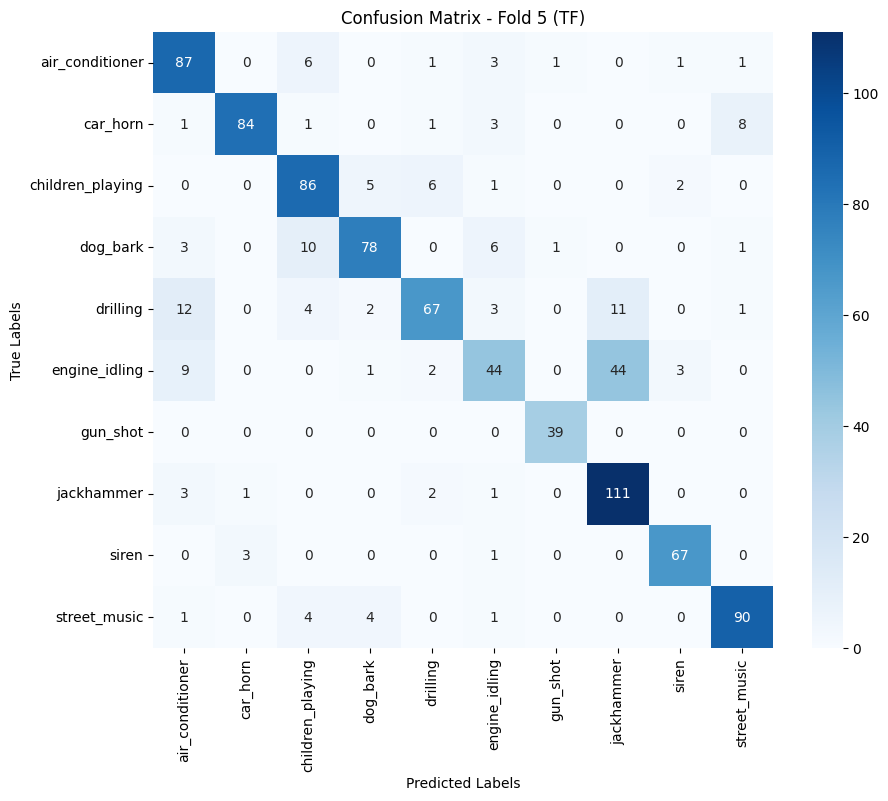


--- Inizio Fold 6/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 3, 4, 5, 7, 8, 9, 10]
Fold di Test: [6]


Caricamento per fold [1, 2, 3, 4, 5, 7, 8, 9, 10]:   0%|          | 0/7909 [00:00<?, ?it/s]

Trovati 7909 file per i fold [1, 2, 3, 4, 5, 7, 8, 9, 10]


Caricamento per fold [6]:   0%|          | 0/823 [00:00<?, ?it/s]

Trovati 823 file per i fold [6]
Inizio training per fold 6...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


247/247 ━━━━━━━━━━━━━━━━━━━━ 68s 260ms/step - accuracy: 0.6411 - loss: 1.1009 - val_accuracy: 0.6963 - val_loss: 1.0435
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 261ms/step - accuracy: 0.9199 - loss: 0.2652 - val_accuracy: 0.6862 - val_loss: 1.3013
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.9796 - loss: 0.0945 - val_accuracy: 0.7150 - val_loss: 1.1802
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 259ms/step - accuracy: 0.9893 - loss: 0.0463 - val_accuracy: 0.7287 - val_loss: 1.2669
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 65s 261ms/step - accuracy: 0.9957 - loss: 0.0255 - val_accuracy: 0.6988 - val_loss: 1.4980
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 65s 262ms/step - accuracy: 0.9978 - loss: 0.0133 - val_accuracy: 0.7362 - val_loss: 1.3399
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.9989 - loss: 0.0096 - val_accuracy: 0.7625 - val_loss: 1.2007
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 260ms/step - accuracy: 0.9974 - loss: 0.0102 - val

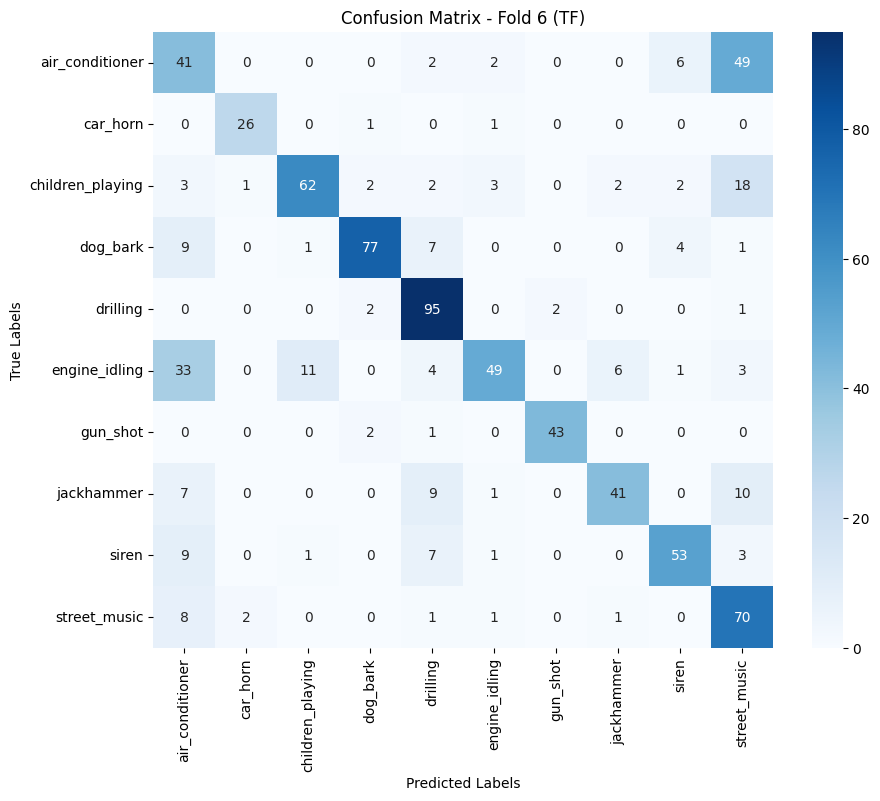


--- Inizio Fold 7/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 3, 4, 5, 6, 8, 9, 10]
Fold di Test: [7]


Caricamento per fold [1, 2, 3, 4, 5, 6, 8, 9, 10]:   0%|          | 0/7894 [00:00<?, ?it/s]

Trovati 7894 file per i fold [1, 2, 3, 4, 5, 6, 8, 9, 10]


Caricamento per fold [7]:   0%|          | 0/838 [00:00<?, ?it/s]

Trovati 838 file per i fold [7]
Inizio training per fold 7...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


246/246 ━━━━━━━━━━━━━━━━━━━━ 70s 267ms/step - accuracy: 0.6098 - loss: 1.1629 - val_accuracy: 0.6274 - val_loss: 1.0518
Epoch 2/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.9024 - loss: 0.3142 - val_accuracy: 0.7031 - val_loss: 0.9006
Epoch 3/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.9650 - loss: 0.1328 - val_accuracy: 0.6803 - val_loss: 1.1382
Epoch 4/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 64s 261ms/step - accuracy: 0.9916 - loss: 0.0502 - val_accuracy: 0.7188 - val_loss: 1.0520
Epoch 5/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 67s 271ms/step - accuracy: 0.9951 - loss: 0.0276 - val_accuracy: 0.7572 - val_loss: 0.8696
Epoch 6/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 64s 261ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.7464 - val_loss: 1.0210
Epoch 7/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 64s 260ms/step - accuracy: 0.9994 - loss: 0.0054 - val_accuracy: 0.7704 - val_loss: 0.8690
Epoch 8/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 63s 258ms/step - accuracy: 1.0000 - loss: 0.0017 - val

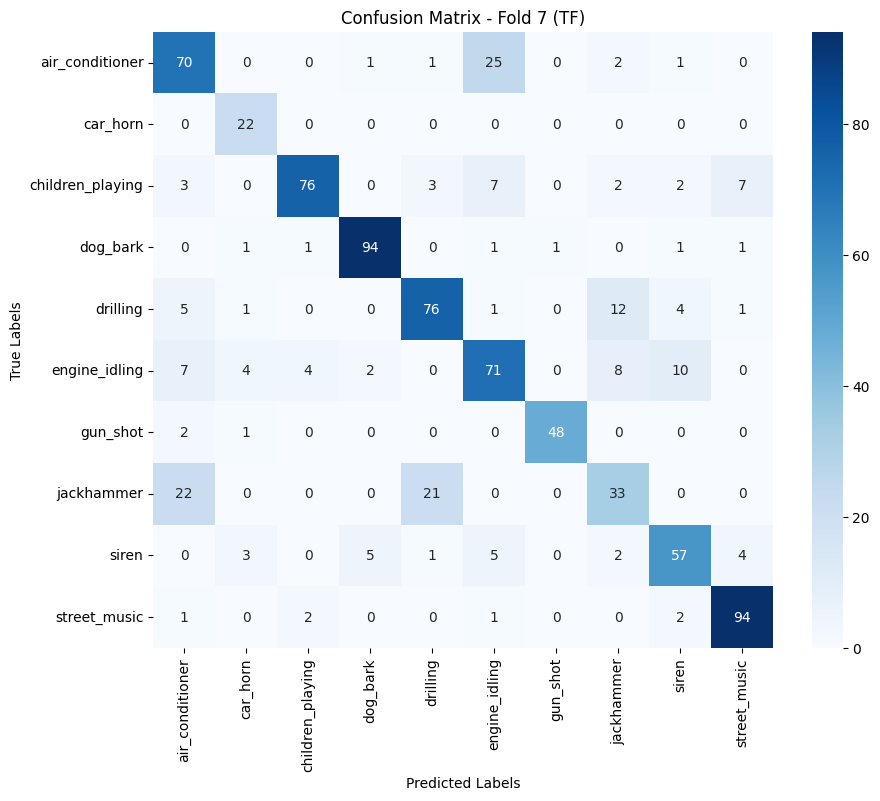


--- Inizio Fold 8/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 3, 4, 5, 6, 7, 9, 10]
Fold di Test: [8]


Caricamento per fold [1, 2, 3, 4, 5, 6, 7, 9, 10]:   0%|          | 0/7926 [00:00<?, ?it/s]

Trovati 7926 file per i fold [1, 2, 3, 4, 5, 6, 7, 9, 10]


Caricamento per fold [8]:   0%|          | 0/806 [00:00<?, ?it/s]

Trovati 806 file per i fold [8]
Inizio training per fold 8...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


247/247 ━━━━━━━━━━━━━━━━━━━━ 69s 264ms/step - accuracy: 0.6236 - loss: 1.1098 - val_accuracy: 0.6712 - val_loss: 1.1728
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 65s 263ms/step - accuracy: 0.9225 - loss: 0.2676 - val_accuracy: 0.6662 - val_loss: 1.1592
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.9693 - loss: 0.1154 - val_accuracy: 0.6600 - val_loss: 1.3386
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 65s 263ms/step - accuracy: 0.9868 - loss: 0.0568 - val_accuracy: 0.6237 - val_loss: 1.6464
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 260ms/step - accuracy: 0.9945 - loss: 0.0296 - val_accuracy: 0.6363 - val_loss: 1.6095
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 66s 267ms/step - accuracy: 0.9974 - loss: 0.0127 - val_accuracy: 0.6725 - val_loss: 1.4751
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.9993 - loss: 0.0062 - val_accuracy: 0.6825 - val_loss: 1.4901
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.9992 - loss: 0.0040 - val

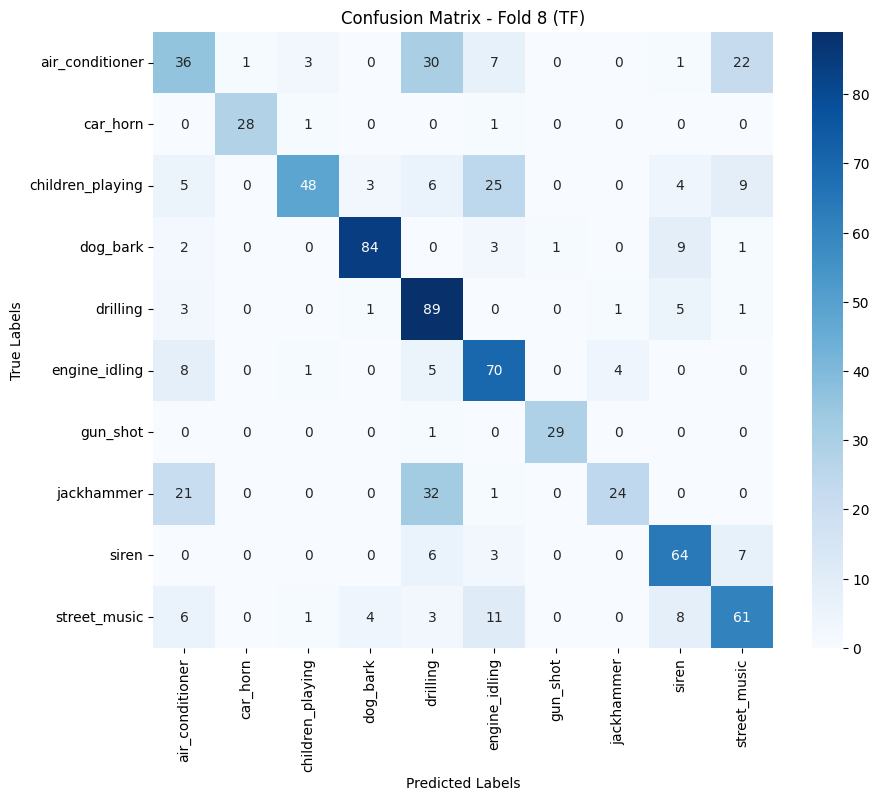


--- Inizio Fold 9/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 3, 4, 5, 6, 7, 8, 10]
Fold di Test: [9]


Caricamento per fold [1, 2, 3, 4, 5, 6, 7, 8, 10]:   0%|          | 0/7916 [00:00<?, ?it/s]

Trovati 7916 file per i fold [1, 2, 3, 4, 5, 6, 7, 8, 10]


Caricamento per fold [9]:   0%|          | 0/816 [00:00<?, ?it/s]

Trovati 816 file per i fold [9]
Inizio training per fold 9...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


247/247 ━━━━━━━━━━━━━━━━━━━━ 69s 262ms/step - accuracy: 0.6320 - loss: 1.0929 - val_accuracy: 0.7225 - val_loss: 0.9885
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 65s 264ms/step - accuracy: 0.9179 - loss: 0.2627 - val_accuracy: 0.7613 - val_loss: 0.9580
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 261ms/step - accuracy: 0.9709 - loss: 0.1085 - val_accuracy: 0.7812 - val_loss: 0.9239
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 260ms/step - accuracy: 0.9895 - loss: 0.0440 - val_accuracy: 0.7600 - val_loss: 1.0985
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 63s 256ms/step - accuracy: 0.9959 - loss: 0.0253 - val_accuracy: 0.7325 - val_loss: 1.1450
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 257ms/step - accuracy: 0.9964 - loss: 0.0231 - val_accuracy: 0.7738 - val_loss: 1.0625
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 257ms/step - accuracy: 0.9978 - loss: 0.0114 - val_accuracy: 0.7725 - val_loss: 1.1168
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 260ms/step - accuracy: 0.9997 - loss: 0.0029 - val

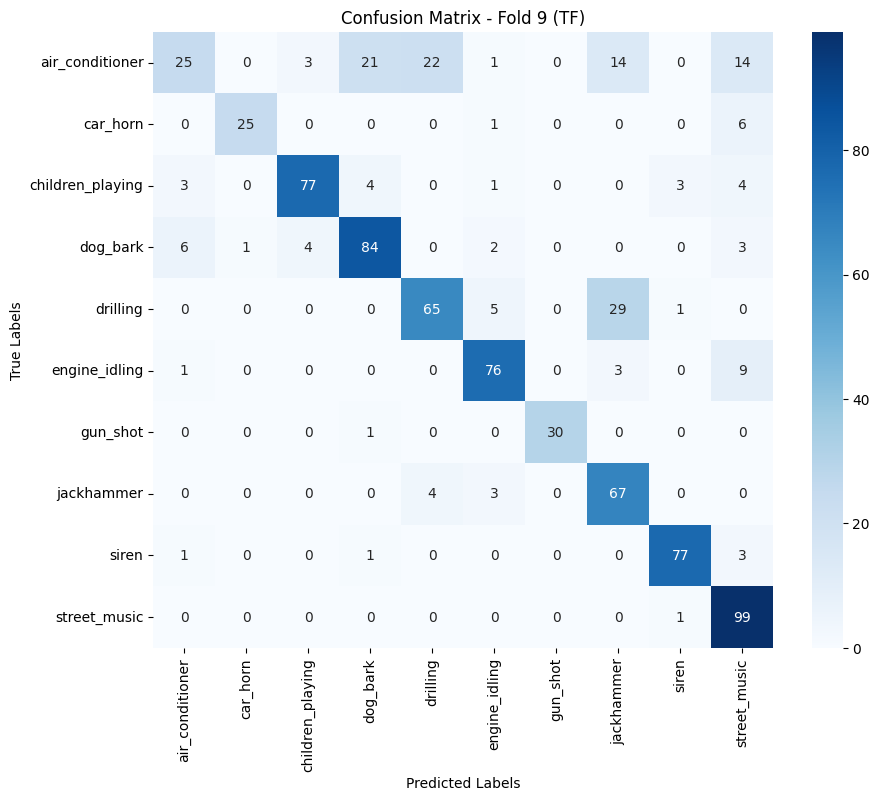


--- Inizio Fold 10/10 (TensorFlow/Keras) ---
Fold di Training: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Fold di Test: [10]


Caricamento per fold [1, 2, 3, 4, 5, 6, 7, 8, 9]:   0%|          | 0/7895 [00:00<?, ?it/s]

Trovati 7895 file per i fold [1, 2, 3, 4, 5, 6, 7, 8, 9]


Caricamento per fold [10]:   0%|          | 0/837 [00:00<?, ?it/s]

Trovati 837 file per i fold [10]
Inizio training per fold 10...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


246/246 ━━━━━━━━━━━━━━━━━━━━ 71s 272ms/step - accuracy: 0.6245 - loss: 1.1010 - val_accuracy: 0.6166 - val_loss: 1.3917
Epoch 2/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 63s 258ms/step - accuracy: 0.9130 - loss: 0.2828 - val_accuracy: 0.7200 - val_loss: 0.9841
Epoch 3/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 65s 262ms/step - accuracy: 0.9645 - loss: 0.1293 - val_accuracy: 0.7524 - val_loss: 0.8999
Epoch 4/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 65s 264ms/step - accuracy: 0.9835 - loss: 0.0653 - val_accuracy: 0.7644 - val_loss: 0.8863
Epoch 5/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 64s 260ms/step - accuracy: 0.9955 - loss: 0.0246 - val_accuracy: 0.7656 - val_loss: 0.9279
Epoch 6/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 65s 264ms/step - accuracy: 0.9969 - loss: 0.0131 - val_accuracy: 0.7981 - val_loss: 0.7985
Epoch 7/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 67s 271ms/step - accuracy: 0.9983 - loss: 0.0103 - val_accuracy: 0.7873 - val_loss: 0.9584
Epoch 8/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 70s 284ms/step - accuracy: 0.9996 - loss: 0.0029 - val

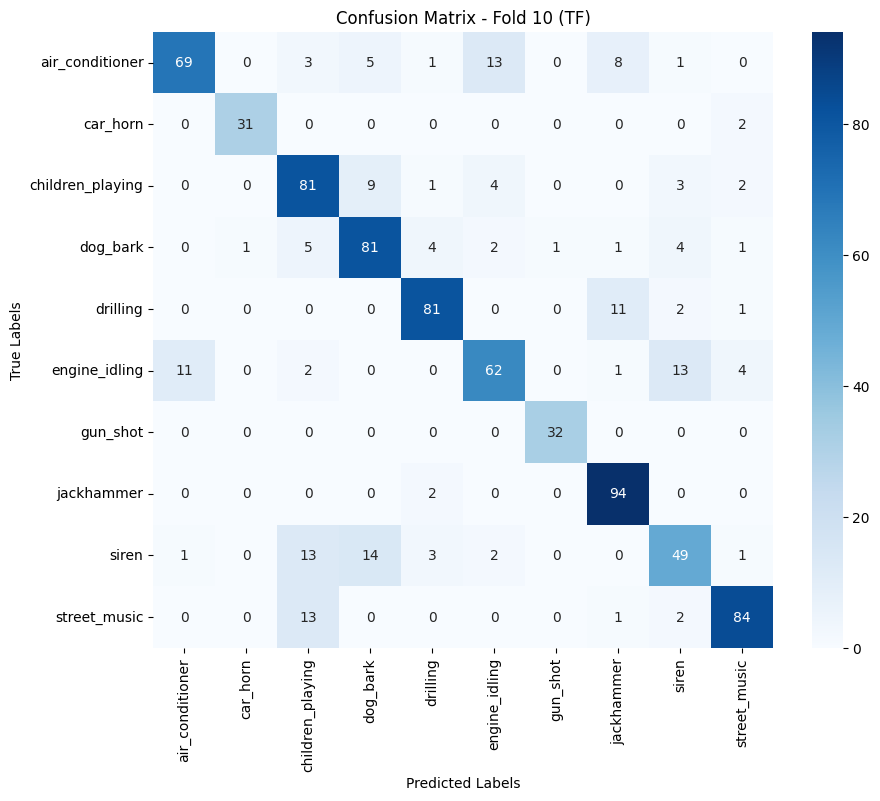

In [6]:
# Blocco 6: Loop di K-Fold Cross-Validation (TensorFlow/Keras)
# ============================================================

num_folds = 10
fold_results_tf = []

if not os.path.exists(FEATURES_PATH):
    print(f"ERRORE: La cartella delle feature '{FEATURES_PATH}' non esiste.")
    # exit()

for fold_idx in range(1, num_folds + 1):
    print(f"\n--- Inizio Fold {fold_idx}/{num_folds} (TensorFlow/Keras) ---")

    train_fold_numbers = [f for f in range(1, num_folds + 1) if f != fold_idx]
    test_fold_numbers = [fold_idx]

    print(f"Fold di Training: {train_fold_numbers}")
    print(f"Fold di Test: {test_fold_numbers}")

    # --- Creazione DataGenerator ---
    train_generator = UrbanSoundDataGenerator(metadata_df, FEATURES_PATH, train_fold_numbers, BATCH_SIZE, FEATURE_TYPE, NUM_CLASSES, shuffle=True)
    test_generator = UrbanSoundDataGenerator(metadata_df, FEATURES_PATH, test_fold_numbers, BATCH_SIZE, FEATURE_TYPE, NUM_CLASSES, shuffle=False)

    if len(train_generator) == 0 or len(test_generator) == 0 or train_generator.input_shape is None:
        print(f"Errore: Generatori dati per fold {fold_idx} non validi o input_shape non determinata. Salto il fold.")
        fold_results_tf.append({ # Aggiungi un risultato vuoto o di errore
            'fold': fold_idx, 'accuracy': 0, 'f1_macro': 0, 'f1_weighted': 0, 
            'loss': float('inf'), 'report': "Error", 'cm': np.zeros((NUM_CLASSES, NUM_CLASSES)),
            'history': None
        })
        continue
    
    # --- Costruzione e Compilazione Modello ---
    # Usa input_shape dal generatore (più robusto)
    model = build_cnngru_model(train_generator.input_shape, NUM_CLASSES, FEATURE_TYPE)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy', # Usa questa se le etichette sono interi (0, 1, 2...)
        # loss='categorical_crossentropy', # Usa questa se le etichette sono one-hot encoded
        metrics=['accuracy']
    )
    # model.summary() # Visualizza la struttura del modello per il primo fold

    # --- Callbacks (opzionale) ---
    # EarlyStopping per fermare il training se non ci sono miglioramenti
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    # ReduceLROnPlateau per ridurre il learning rate
    # reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)

    print(f"Inizio training per fold {fold_idx}...")
    history = model.fit(
        train_generator,
        epochs=NUM_EPOCHS,
        validation_data=test_generator, # Keras usa il test set come validation set qui.
                                        # Idealmente, avresti un validation_generator separato.
        callbacks=[early_stopping], # Aggiungi reduce_lr se vuoi
        verbose=1 # 0=silenzioso, 1=progress bar, 2=una linea per epoca
    )

    # --- Valutazione Finale sul Test Set per questo Fold ---
    # Se EarlyStopping ha restore_best_weights=True, il modello ha già i pesi migliori
    print(f"\nValutazione finale per Fold {fold_idx} sul Test Set:")
    # Keras model.evaluate restituisce [loss, accuracy] (o altre metriche definite in compile)
    loss, accuracy = model.evaluate(test_generator, verbose=0)

    # Per F1 score e classification report, dobbiamo fare predizioni
    y_pred_proba = model.predict(test_generator)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Ottieni le etichette vere dal generatore di test
    # Questo è un po' macchinoso con Keras Sequence, devi iterare
    y_true = []
    for i in range(len(test_generator)):
        _, labels_batch = test_generator[i]
        y_true.extend(labels_batch)
    y_true = np.array(y_true)[:len(y_pred)] # Assicura che le lunghezze corrispondano (potrebbe esserci un batch parziale alla fine)


    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"Fold {fold_idx} - Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
    print(f"Fold {fold_idx} - F1 Score (Macro): {f1_macro:.4f}, F1 Score (Weighted): {f1_weighted:.4f}")
    
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    print(f"\nClassification Report per Fold {fold_idx}:\n{report}")
    
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
    plot_confusion_matrix_tf(cm, class_names, fold_idx)
    
    fold_results_tf.append({
        'fold': fold_idx,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'loss': loss,
        'report': report,
        'cm': cm,
        'history': history.history # Salva la storia del training
    })
    
    # Pulisci la sessione Keras per liberare memoria (importante in un loop lungo)
    keras.backend.clear_session()
    del model, train_generator, test_generator, history
    # gc.collect() # Garbage collection esplicito



--- Risultati Complessivi della Cross-Validation (TensorFlow/Keras) ---

Feature Type Utilizzato: log_mel_spec
Accuratezza Media: 0.7147 +/- 0.0688
F1 Score Macro Medio: 0.7345 +/- 0.0599
F1 Score Weighted Medio: 0.7071 +/- 0.0717

Accuratezze per Fold (validi):
Fold 1: 0.6447
Fold 2: 0.6447
Fold 3: 0.6105
Fold 4: 0.7240
Fold 5: 0.8114
Fold 6: 0.6963
Fold 7: 0.7704
Fold 8: 0.6662
Fold 9: 0.7812
Fold 10: 0.7981


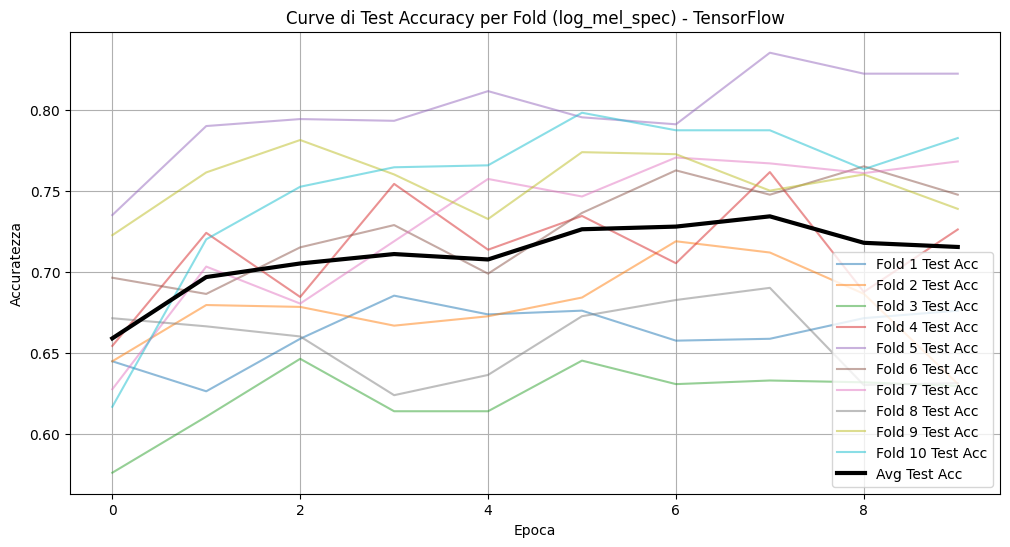

In [7]:
# Blocco 7: Visualizzazione dei Risultati Complessivi (TensorFlow/Keras)
# ======================================================================

if fold_results_tf and any(res['history'] is not None for res in fold_results_tf): # Controlla che ci siano risultati validi
    print("\n\n--- Risultati Complessivi della Cross-Validation (TensorFlow/Keras) ---")
    
    # Filtra i risultati che potrebbero essere falliti (accuracy = 0, loss = inf)
    valid_results = [res for res in fold_results_tf if res['accuracy'] > 0 and res['history'] is not None]

    if not valid_results:
        print("Nessun risultato valido dai fold da visualizzare.")
    else:
        accuracies = [res['accuracy'] for res in valid_results]
        f1_macros = [res['f1_macro'] for res in valid_results]
        f1_weighteds = [res['f1_weighted'] for res in valid_results]

        mean_accuracy = np.mean(accuracies)
        std_accuracy = np.std(accuracies)
        mean_f1_macro = np.mean(f1_macros)
        std_f1_macro = np.std(f1_macros)
        mean_f1_weighted = np.mean(f1_weighteds)
        std_f1_weighted = np.std(f1_weighteds)

        print(f"\nFeature Type Utilizzato: {FEATURE_TYPE}")
        print(f"Accuratezza Media: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
        print(f"F1 Score Macro Medio: {mean_f1_macro:.4f} +/- {std_f1_macro:.4f}")
        print(f"F1 Score Weighted Medio: {mean_f1_weighted:.4f} +/- {std_f1_weighted:.4f}")

        print("\nAccuratezze per Fold (validi):")
        for res in valid_results:
            print(f"Fold {res['fold']}: {res['accuracy']:.4f}")

        # Plot curve di apprendimento
        plt.figure(figsize=(12, 6))
        for res in valid_results:
             # 'val_accuracy' è la metrica di accuratezza sul validation_data (qui il test_generator)
            if 'val_accuracy' in res['history']:
                 plt.plot(res['history']['val_accuracy'], label=f'Fold {res["fold"]} Test Acc', alpha=0.5)
        
        # Calcola la media delle curve di val_accuracy
        # Le storie potrebbero avere lunghezze diverse a causa di EarlyStopping
        # Troviamo la lunghezza minima tra le storie valide
        if valid_results:
            min_epochs_completed = min(len(res['history']['val_accuracy']) for res in valid_results if 'val_accuracy' in res['history'] and res['history']['val_accuracy'])
            
            avg_val_acc_curves = []
            for res in valid_results:
                if 'val_accuracy' in res['history'] and res['history']['val_accuracy']:
                    avg_val_acc_curves.append(res['history']['val_accuracy'][:min_epochs_completed])
            
            if avg_val_acc_curves:
                avg_val_acc_curve = np.mean(avg_val_acc_curves, axis=0)
                plt.plot(avg_val_acc_curve, label='Avg Test Acc', linewidth=3, color='black')
        
        plt.title(f'Curve di Test Accuracy per Fold ({FEATURE_TYPE}) - TensorFlow')
        plt.xlabel('Epoca')
        plt.ylabel('Accuratezza')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.show()
else:
    print("Nessun risultato dai fold da visualizzare o tutti i fold hanno fallito. Controlla eventuali errori precedenti.")

Analisi sintetica dei risultati:

- **Accuratezza Media:** 0.7147 ± 0.0688  
    Un’accuratezza media del 71.5% è un buon risultato per una classificazione a 10 classi su UrbanSound8K, soprattutto senza data augmentation avanzata o tuning approfondito degli iperparametri. La deviazione standard di circa 0.069 (7%) indica una variabilità tra i fold, normale in dataset complessi: alcuni fold risultano più semplici o difficili, anche per la diversa distribuzione delle classi.

- **F1 Score Macro Medio:** 0.7345 ± 0.0599  
    L’F1 Macro, che dà lo stesso peso a ogni classe, raggiunge il 73.4%. Questo valore superiore all’accuratezza suggerisce che il modello si comporta discretamente anche sulle classi meno rappresentate. La deviazione standard (6%) conferma la variabilità tra i fold.

- **F1 Score Weighted Medio:** 0.7071 ± 0.0717  
    L’F1 Weighted, che pesa le classi in base al support, è leggermente inferiore agli altri indicatori. Questo può indicare che il modello ha performance un po’ inferiori sulle classi più numerose, oppure che le classi meno popolate (pur avendo buoni risultati) non incidono molto sulla media pesata.

- **Accuratezze per Fold:**  
    Si osserva una variazione significativa: dal 61.05% (Fold 3, il più difficile) all’81.14% (Fold 5, il migliore). Fold 10 mostra anch’esso ottime prestazioni. Questa variabilità sottolinea l’importanza della K-Fold Cross-Validation, che offre una valutazione più robusta rispetto a un singolo split train/test.


--- Analisi del Modello del Fold Migliore ---
Il Fold con la migliore accuratezza è il Fold 5 con un'accuratezza di 0.8114
Configurazione per il Fold migliore (Fold 5):
  Fold di Training: [1, 2, 3, 4, 6, 7, 8, 9, 10]
  Fold di Test: [5]


Caricamento per fold [1, 2, 3, 4, 6, 7, 8, 9, 10]:   0%|          | 0/7796 [00:00<?, ?it/s]

Trovati 7796 file per i fold [1, 2, 3, 4, 6, 7, 8, 9, 10]


Caricamento per fold [5]:   0%|          | 0/936 [00:00<?, ?it/s]

Trovati 936 file per i fold [5]
Input shape per il modello: (128, 173, 1)

Ri-addestramento del modello per la configurazione del Fold 5...
Epoch 1/10


c:\Users\luca-\OneDrive\Desktop\University\MAGISTRALE\2_ANNO\2_SEMESTRE\ai_from_eng_to_arts\urbanSmartSound\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


243/243 ━━━━━━━━━━━━━━━━━━━━ 70s 273ms/step - accuracy: 0.6073 - loss: 1.1760 - val_accuracy: 0.6853 - val_loss: 0.8717
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 69s 283ms/step - accuracy: 0.9050 - loss: 0.3091 - val_accuracy: 0.7522 - val_loss: 0.7205
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 66s 273ms/step - accuracy: 0.9705 - loss: 0.1225 - val_accuracy: 0.7888 - val_loss: 0.6829
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 66s 271ms/step - accuracy: 0.9873 - loss: 0.0576 - val_accuracy: 0.7414 - val_loss: 0.7606
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 66s 272ms/step - accuracy: 0.9915 - loss: 0.0340 - val_accuracy: 0.7985 - val_loss: 0.6242
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 64s 265ms/step - accuracy: 0.9966 - loss: 0.0141 - val_accuracy: 0.7565 - val_loss: 0.9920
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 66s 273ms/step - accuracy: 0.9992 - loss: 0.0075 - val_accuracy: 0.7963 - val_loss: 0.6308
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 66s 271ms/step - accuracy: 0.9990 - loss: 0.0049 - val

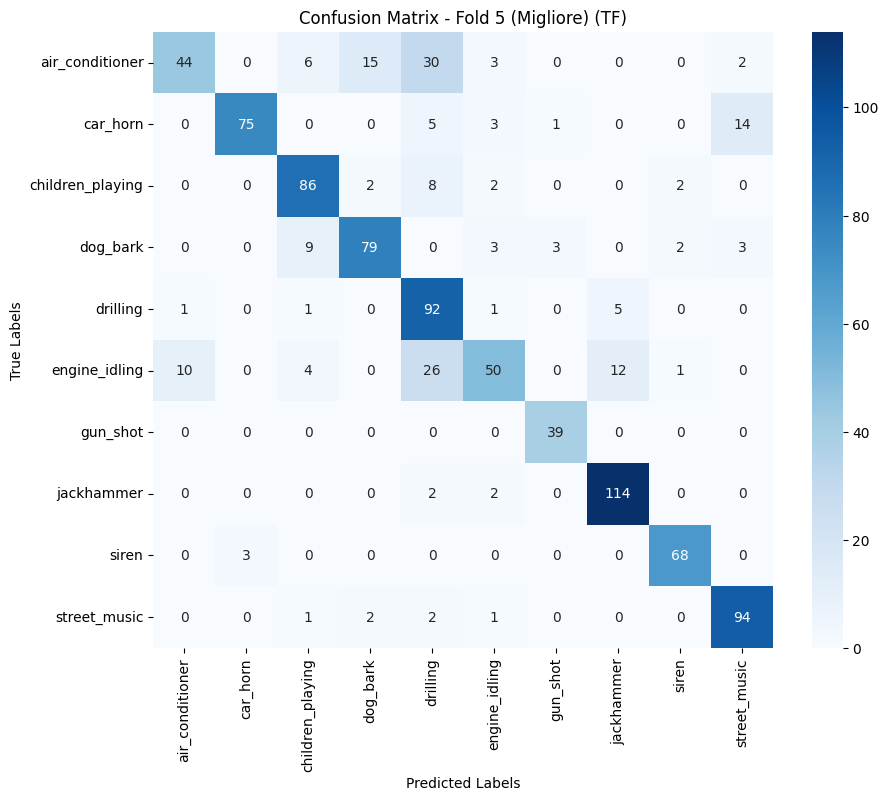


Modello del Fold 5 (ri-addestrato) salvato in: best_model_fold_5_log_mel_spec.keras


In [8]:
# Blocco 8: Analisi e Salvataggio del Modello del Fold Migliore
# ============================================================
# Questo blocco identifica il fold con la migliore accuratezza dalla K-Fold,
# ri-addestra il modello per quella configurazione di fold, lo valuta,
# mostra statistiche dettagliate e lo salva.

import operator # Per trovare il fold migliore

if not fold_results_tf or not any(res.get('accuracy', 0) > 0 for res in fold_results_tf):
    print("Nessun risultato valido dalla K-Fold Cross-Validation trovato in 'fold_results_tf'.")
    print("Assicurati che il Blocco 6 sia stato eseguito correttamente e che 'fold_results_tf' contenga i risultati.")
else:
    print("\n--- Analisi del Modello del Fold Migliore ---")

    # 1. Identifica il fold con la migliore accuratezza
    # Assumiamo che fold_results_tf sia una lista di dizionari con chiavi 'fold' e 'accuracy'
    best_fold_info = max(filter(lambda x: x.get('accuracy', 0) > 0, fold_results_tf), key=operator.itemgetter('accuracy'))
    best_fold_idx = best_fold_info['fold']
    best_fold_accuracy = best_fold_info['accuracy']

    print(f"Il Fold con la migliore accuratezza è il Fold {best_fold_idx} con un'accuratezza di {best_fold_accuracy:.4f}")

    # 2. Prepara i dati per ri-addestrare/valutare il modello per questo fold specifico
    # Il 'best_fold_idx' sarà il nostro TEST set, gli altri per TRAINING
    
    train_fold_numbers_best = [f for f in range(1, num_folds + 1) if f != best_fold_idx]
    test_fold_numbers_best = [best_fold_idx]

    print(f"Configurazione per il Fold migliore (Fold {best_fold_idx}):")
    print(f"  Fold di Training: {train_fold_numbers_best}")
    print(f"  Fold di Test: {test_fold_numbers_best}")

    # Crea i DataGenerator
    train_generator_best_fold = UrbanSoundDataGenerator(
        metadata_df, FEATURES_PATH, train_fold_numbers_best, BATCH_SIZE,
        FEATURE_TYPE, NUM_CLASSES, shuffle=True
    )
    # Il test_generator_best_fold conterrà solo i dati del best_fold_idx
    test_generator_best_fold = UrbanSoundDataGenerator(
        metadata_df, FEATURES_PATH, test_fold_numbers_best, BATCH_SIZE,
        FEATURE_TYPE, NUM_CLASSES, shuffle=False
    )

    if len(train_generator_best_fold) == 0 or train_generator_best_fold.input_shape is None:
        print(f"Errore: Train generator per il Fold {best_fold_idx} è vuoto o input_shape non determinata.")
    elif len(test_generator_best_fold) == 0 or test_generator_best_fold.input_shape is None:
        print(f"Errore: Test generator per il Fold {best_fold_idx} è vuoto o input_shape non determinata.")
    else:
        print(f"Input shape per il modello: {train_generator_best_fold.input_shape}")

        # 3. Costruisci, Compila e (Ri)Addestra il Modello
        print(f"\nRi-addestramento del modello per la configurazione del Fold {best_fold_idx}...")
        
        # Assicurati di usare gli stessi iperparametri usati nel Blocco 6
        # (LEARNING_RATE, NUM_EPOCHS, architettura del modello, ecc.)
        model_best_fold = build_cnngru_model(
            train_generator_best_fold.input_shape, 
            NUM_CLASSES, 
            FEATURE_TYPE
            # Se avevi iperparametri specifici per cnn_filters, gru_units, etc., mettili qui
        )

        model_best_fold.compile(
            optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Callbacks (opzionale, ma EarlyStopping è buona)
        # Usa gli stessi parametri di EarlyStopping del Blocco 6 se possibile
        early_stopping_best_fold = keras.callbacks.EarlyStopping(
            monitor='val_loss',  # Monitora la loss sul validation set (che è il test set del fold qui)
            patience=10,         # Numero di epoche senza miglioramenti prima di fermarsi
            restore_best_weights=True, # Ripristina i pesi del modello dall'epoca con la miglior val_loss
            verbose=1
        )

        history_best_fold = model_best_fold.fit(
            train_generator_best_fold,
            epochs=NUM_EPOCHS, # Usa lo stesso NUM_EPOCHS del Blocco 6
            validation_data=test_generator_best_fold, # Valida sul test set del fold
            callbacks=[early_stopping_best_fold],
            verbose=1
        )

        print("\nAddestramento per il Fold migliore completato.")

        # 4. Valuta il Modello Ri-Addestrato sul suo Test Set (Fold migliore)
        print(f"\nValutazione del modello (ri-addestrato) del Fold {best_fold_idx} sul suo set di test (Fold {best_fold_idx})...")
        
        loss_best_fold, accuracy_best_fold_eval = model_best_fold.evaluate(
            test_generator_best_fold, 
            verbose=0
        )
        
        y_pred_proba_best_fold = model_best_fold.predict(test_generator_best_fold)
        y_pred_best_fold = np.argmax(y_pred_proba_best_fold, axis=1)

        y_true_best_fold = []
        for i in range(len(test_generator_best_fold)):
            _, labels_batch = test_generator_best_fold[i]
            y_true_best_fold.extend(labels_batch)
        y_true_best_fold = np.array(y_true_best_fold)[:len(y_pred_best_fold)]

        f1_macro_best_fold = f1_score(y_true_best_fold, y_pred_best_fold, average='macro', zero_division=0)
        f1_weighted_best_fold = f1_score(y_true_best_fold, y_pred_best_fold, average='weighted', zero_division=0)

        print(f"\nStatistiche Globali per il Modello del Fold {best_fold_idx} (dopo ri-addestramento):")
        print(f"  Accuratezza: {accuracy_best_fold_eval:.4f} (Confronta con: {best_fold_accuracy:.4f} dalla K-Fold)")
        print(f"  Loss: {loss_best_fold:.4f}")
        print(f"  F1 Score (Macro): {f1_macro_best_fold:.4f}")
        print(f"  F1 Score (Weighted): {f1_weighted_best_fold:.4f}")

        # Classification Report
        print(f"\nClassification Report per il Modello del Fold {best_fold_idx}:")
        # class_names dovrebbe essere già definito dal Blocco 5 o 1
        report_best_fold = classification_report(y_true_best_fold, y_pred_best_fold, target_names=class_names, zero_division=0)
        print(report_best_fold)

        # Matrice di Confusione
        print(f"\nMatrice di Confusione per il Modello del Fold {best_fold_idx}:")
        cm_best_fold = confusion_matrix(y_true_best_fold, y_pred_best_fold, labels=range(NUM_CLASSES))
        
        # plot_confusion_matrix_tf dovrebbe essere già definita dal Blocco 5
        plot_confusion_matrix_tf(cm_best_fold, class_names, f"{best_fold_idx} (Migliore)")
        plt.show() # Assicurati che il plot venga visualizzato

        # 5. Salva il Modello del Fold Migliore
        model_save_path_best_fold = f"best_model_fold_{best_fold_idx}_{FEATURE_TYPE}.keras"
        model_best_fold.save(model_save_path_best_fold)
        print(f"\nModello del Fold {best_fold_idx} (ri-addestrato) salvato in: {model_save_path_best_fold}")

        # Pulisci la sessione per il prossimo eventuale ri-addestramento o per liberare memoria
        keras.backend.clear_session()
        del model_best_fold, train_generator_best_fold, test_generator_best_fold, history_best_fold
        # gc.collect() # Opzionale